In [15]:
import seaborn as sns

In [16]:
titanic_df = sns.load_dataset('titanic')
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [17]:
# 컬럼 의미
print("""
survived : 생존 여부 (0=사망, 1=생존) ← 예측 대상(Target)
pclass   : 객실 등급 (1=1등석, 2=2등석, 3=3등석)
sex      : 성별
age      : 나이
sibsp    : 형제·배우자 탑승 수
parch    : 부모·자녀 탑승 수
fare     : 요금
embarked : 탑승 항구 (C=셰르부르, Q=퀸스타운, S=사우샘프턴)
""")
titanic_df.info()


survived : 생존 여부 (0=사망, 1=생존) ← 예측 대상(Target)
pclass   : 객실 등급 (1=1등석, 2=2등석, 3=3등석)
sex      : 성별
age      : 나이
sibsp    : 형제·배우자 탑승 수
parch    : 부모·자녀 탑승 수
fare     : 요금
embarked : 탑승 항구 (C=셰르부르, Q=퀸스타운, S=사우샘프턴)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 

In [18]:
cols = titanic_df.columns[0:8]
df = titanic_df[cols]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [19]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
# df.info() # 결측값 확인
# df.isnull().sum() # 결측값 확인

# age: 중앙값 대체 (이상값의 영향을 적게 받는 통계량 사용)
df['age'] = df['age'].fillna(df['age'].median())

# embarked: 최빈값 대체
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('처리 후 결측치:')
print(df.isnull().sum())

처리 후 결측치:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [21]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [22]:
# 범주형 데이터 (문자열) -> 숫자형으로 변경

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

# 원본 데이터셋 복제
df_enc = df.copy()

le = LabelEncoder() # 범주형 -> 숫자형 변경 도구
df_enc['sex'] = le.fit_transform(df_enc['sex'])     # female=0, male=1

df_enc = pd.get_dummies(df_enc, columns=['embarked'],
                        prefix='port', dtype=int) # OneHotEncoding 처리

print('인코딩 후 컬럼:')
print(df_enc.columns.tolist())
df_enc.head()

인코딩 후 컬럼:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'port_C', 'port_Q', 'port_S']


,survived,pclass,sex,age,sibsp,parch,fare,port_C,port_Q,port_S
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,0,0,1


In [29]:
# 숫자형 변수 스케일 조정 ( 각 변수의 값 범위를 동일하게 만드는 조정 )

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scale_cols = ['age', 'fare']
# scaler = StandardScaler() # 입력 값을 평균 0, 표준편차 1의 분포로 변경
scaler = MinMaxScaler() # 입력 값을 0 ~ 1의 값으로 변경
df_enc[scale_cols] = scaler.fit_transform(df[scale_cols])

print('정규화 후 통계:')
print(df_enc[scale_cols].describe().round(3))

정규화 후 통계:
           age     fare
count  891.000  891.000
mean     0.364    0.063
std      0.164    0.097
min      0.000    0.000
25%      0.271    0.015
50%      0.347    0.028
75%      0.435    0.061
max      1.000    1.000


survived
0    549
1    342
Name: count, dtype: int64


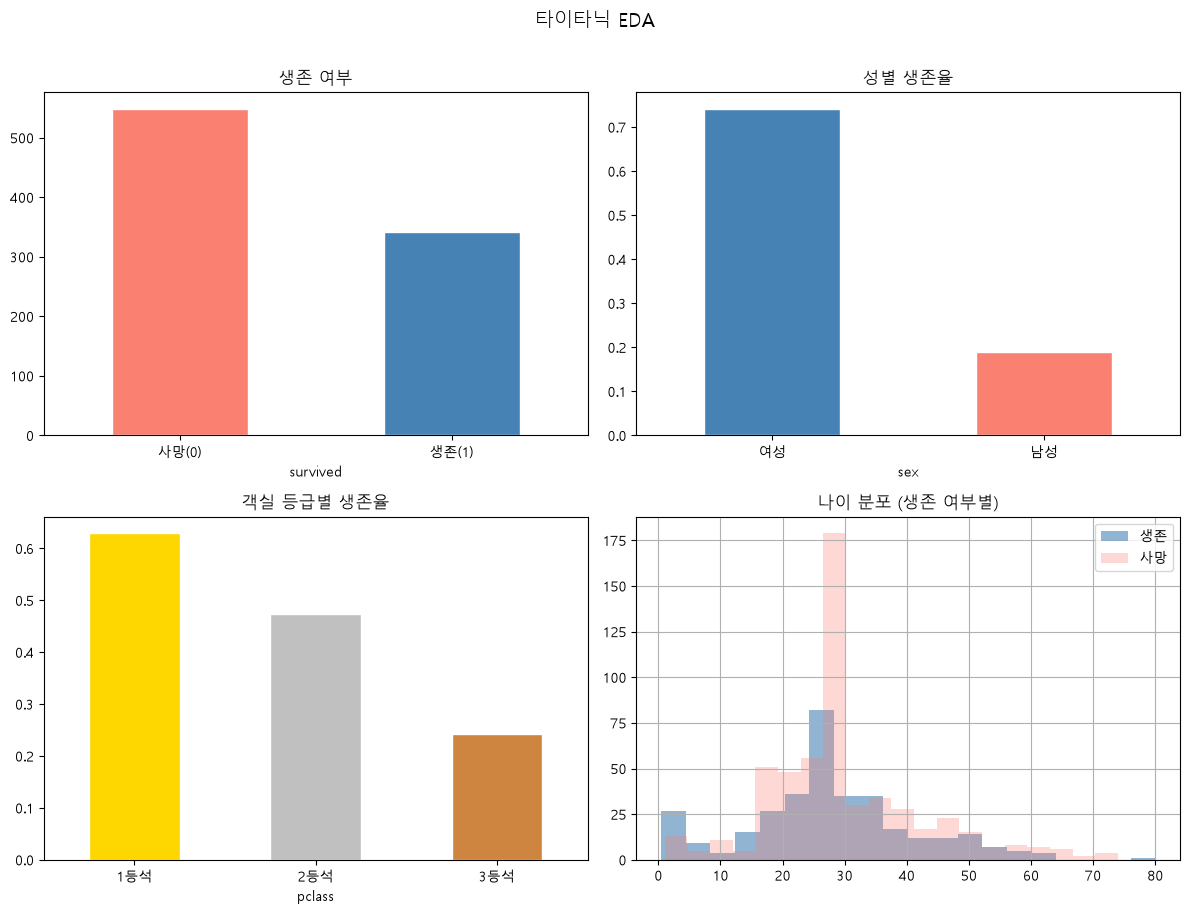

In [38]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"  # 한글 폰트

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

print( df['survived'].value_counts() ) # 값의 종류별로 갯수 계산
# 생존 여부
df['survived'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['salmon','steelblue'], edgecolor='white')
axes[0,0].set_title('생존 여부')
axes[0,0].set_xticklabels(['사망(0)','생존(1)'], rotation=0)

# 성별 생존율
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,1],
    color=['steelblue','salmon'], edgecolor='white')
axes[0,1].set_title('성별 생존율')
axes[0,1].set_xticklabels(['여성','남성'], rotation=0)

# 객실 등급별 생존율
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1,0],
    color=['gold','silver','peru'], edgecolor='white')
axes[1,0].set_title('객실 등급별 생존율')
axes[1,0].set_xticklabels(['1등석','2등석','3등석'], rotation=0)

# 나이 분포 (생존 여부별)
df[df['survived']==1]['age'].hist(bins=20, ax=axes[1,1], alpha=0.6,
                                   label='생존', color='steelblue')
df[df['survived']==0]['age'].hist(bins=20, ax=axes[1,1], alpha=0.3,
                                   label='사망', color='salmon')
axes[1,1].set_title('나이 분포 (생존 여부별)')
axes[1,1].legend()

plt.suptitle('타이타닉 EDA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_titanic.png', dpi=100, bbox_inches='tight')
plt.show()

In [39]:
# 데이터프레임을 파일에 저장
df_enc.to_csv('data-files/data2.csv', index=False)